# 날씨 예측
## 1. 데이터 전처리
### 1-1. 결측치 해결
### 1-2. 풍속에 대한 방향 데이터 개선
## 2. 학습하기
### 2-0. 데이터 나누기
### 2-1. Random Forest
### 2-2. XGBoost
### 2-3. Assemble

## 1. 데이터 전처리
### 1-1. 결측치 해결


In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

In [2]:
train_df = pd.read_csv("data_train.csv")
test_df = pd.read_csv("data_test.csv")

train_df.head()

,temperature(C),wind speed(m/s),wind direction,humidity(%),vapor pressure(hPa),dew point(C),atmospheric pressure(hPa),Sea level pressure(hPa),insolation time(hr),insolation(MJ/m2),cloud,weather label
0,23.1,1.3,90.0,84.0,23.7,20.2,999.3,1005.5,NaN,NaN,10,1
1,25.5,1.1,70.0,63.0,20.5,17.9,1017.3,1018.8,0.9,NaN,4,0
2,4.2,2.1,250.0,88.0,7.2,2.3,1002.9,1030.4,NaN,NaN,8,1
3,5.4,1.0,90.0,21.0,1.9,-15.2,1027.4,1030.8,1.0,NaN,6,3
4,23.6,2.7,250.0,26.0,7.5,2.9,1004.1,1014.4,1.0,3.39,0,0


In [3]:
train_df.info()
train_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   temperature(C)             2056 non-null   float64
 1   wind speed(m/s)            2057 non-null   float64
 2   wind direction             2057 non-null   float64
 3   humidity(%)                2056 non-null   float64
 4   vapor pressure(hPa)        2055 non-null   float64
 5   dew point(C)               2055 non-null   float64
 6   atmospheric pressure(hPa)  2057 non-null   float64
 7   Sea level pressure(hPa)    2056 non-null   float64
 8   insolation time(hr)        1062 non-null   float64
 9   insolation(MJ/m2)          848 non-null    float64
 10  cloud                      2058 non-null   int64  
 11  weather label              2058 non-null   int64  
dtypes: float64(10), int64(2)
memory usage: 193.1 KB


temperature(C)                  2
wind speed(m/s)                 1
wind direction                  1
humidity(%)                     2
vapor pressure(hPa)             3
dew point(C)                    3
atmospheric pressure(hPa)       1
Sea level pressure(hPa)         2
insolation time(hr)           996
insolation(MJ/m2)            1210
cloud                           0
weather label                   0
dtype: int64

- insolation time(hr)  → 996개 결측 (거의 50% 없음)
- insolation(MJ/m2)    → 1210개 결측 (거의 60% 없음)

=> 너무 많이 비어 있어 신뢰도가 떨어짐
=> 두 칼럼 버리기

In [4]:
drop_cols = ["insolation time(hr)", "insolation(MJ/m2)"]

train_df = train_df.drop(columns = drop_cols)
test_df = test_df.drop(columns = drop_cols)

나머지 칼럼의 결측치는 1~3개 수준으로 살려서 쓰기

결측치는 *median*으로 채움

이유) 평균보다 이상치 영향 덜 받으면서 날씨 데이터에 적합함

In [5]:
# 입력과 출력 분리
X = train_df.drop(columns=["weather label"])
y = train_df["weather label"]

imputer = SimpleImputer(strategy = "median")

X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

### 1-2. 방향 데이터 개선

:wind direction 칼럼 처리

지금 상태: 90, 270, 0,...

=> 0도와 360도는 같은 방향인데 모델은 멀다고 생각함

해결) sin(좌우), cos(상하)을 사용해서 2차원 평면 위 고유한 점으로 나타냄

In [6]:
# 라디안 변환 및 sin/cos 계산
X["wind_dir_sin"] = np.sin(np.radians(X["wind direction"]))
X["wind_dir_cos"] = np.cos(np.radians(X["wind direction"]))

X = X.drop(columns=["wind direction"])

print(X.head)

<bound method NDFrame.head of       temperature(C)  wind speed(m/s)  humidity(%)  vapor pressure(hPa)  \
0               23.1              1.3         84.0                 23.7   
1               25.5              1.1         63.0                 20.5   
2                4.2              2.1         88.0                  7.2   
3                5.4              1.0         21.0                  1.9   
4               23.6              2.7         26.0                  7.5   
...              ...              ...          ...                  ...   
2053            18.7              2.0         67.0                 14.4   
2054             8.8              0.2         80.0                  9.0   
2055            31.0              1.2         63.0                 28.3   
2056            24.4              1.8         81.0                 24.7   
2057            27.1              0.4         84.0                 30.0   

      dew point(C)  atmospheric pressure(hPa)  Sea level pressure(hPa

## 2. 학습하기
### 2-1. Random Forest
Decision Tree의 Forest
Random으로 feature를 선정해 node로 지정하고, 분기마다 Decision Tree와 같은 방식으로 지니 불순도를 파악하여 분기해나가는 Weaker learner를 여러개 만들어 비교하고 그 안에서 최적의 예측을 하는 모델이다
1. 부트스트랩 샘플링
RandomForest를 마들기위한 각각의 Weaker learner를 만들기 위해 사용하는 샘플링 방법으로 임의로 Feature를 뽑고, 그 Feature안에서도 임의로 Sample을 복원 추출 하여 뽑는 방법
2. 분기와 임의의 특성 선택
분기 시 다음 특성을 고를 때에도 Random한 방식을 취한다. Bagging이라고 하는 이특징은 BootStrap sampling을 한 Data set에서 Feature를 임의로 선정해 여러 Tree 분류기를 만드는 것으로 Ensemble 기법이라고 할 수 있다.
과적합을 예방해주는 강점이 있다
3. OOB 검증(Out of Bag data validation)
DataSet 내에서 여러개의 New dataset을 복원 추출함으로써 그 자체적인 검증도 어느정도 진행을 한다. 뽑히지 않는 샘플을 검증 셋으로 두어 자체적인 검증을 진행한다.

In [7]:
# 데이터 나누기 공부용(train)과 모의고사용(val)
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train", X_train.shape)
print("Validation:", X_val.shape)

Train (1646, 10)
Validation: (412, 10)


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=100, #100개의 트리
    random_state=42
)

model.fit(X_train, y_train)

pred_val = model.predict(X_val)

#성능 판단
print("Validation Accuracy:", accuracy_score(y_val, pred_val))

Validation Accuracy: 0.7087378640776699


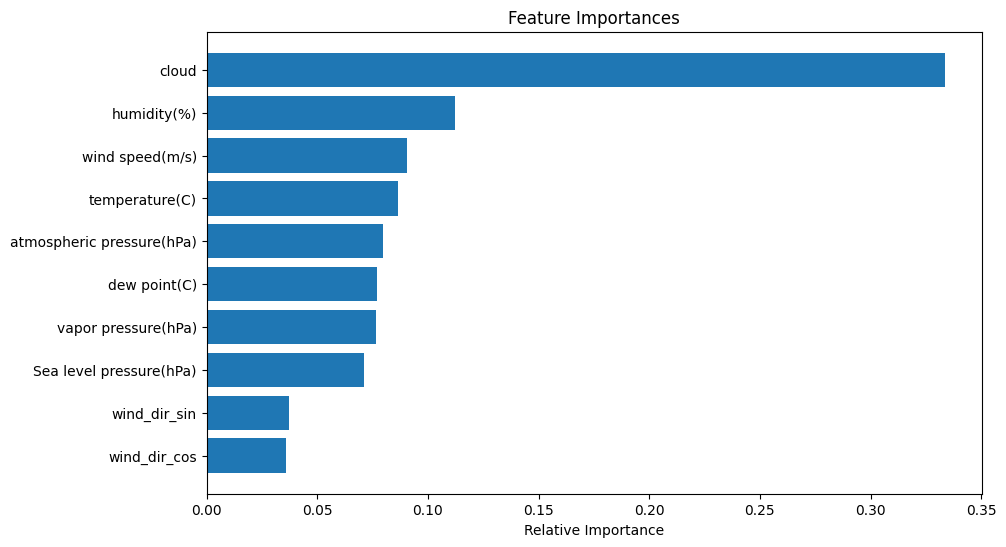

In [9]:
# Feature Importance

import matplotlib.pyplot as plt

importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

#### 파생 변수 만들기
더 성능을 높이고자 변수 조합을 통해 파생 변수를 만들고자 한다.
- 이슬점 편차: 기온과 이슬점이 가까울수록 비가 올 확률이 높다.
- 체감 온도: 습도가 높으면 체감 온도가 올라가고 이는 대기 불안정으로 이어진다
- 기압차: 해면 기압과 현지 기압의 차이를 통해 고도나 대기 상태의 미세한 변화를 포착한다.

In [10]:
# 1. 이슬점 편차
X['temp_dew_diff'] = X['temperature(C)'] - X['dew point(C)']

# 2. 체감 온도
X['apparent_temp'] = X['temperature(C)'] * 0.7 + X['humidity(%)'] * 0.01

# 3. 대기 압력 균형
X['pressure_diff'] = X['Sea level pressure(hPa)'] - X['atmospheric pressure(hPa)']

# 4. 불쾌지수 (THI)
X['THI'] = 1.8 * X['temperature(C)'] - 0.55 * (1 - X['humidity(%)']/100) * (1.8 * X['temperature(C)'] - 26) + 32


#### 불필요한 변수 제거
- 풍향/풍속 결합: 풍향(sin, cos)과 풍속을 곱해 '바람의 벡터' 성분으로 만들기


In [11]:
# 풍향 성분에 풍속의 세기를 반영
X['wind_u'] = X['wind speed(m/s)'] * X['wind_dir_cos']
X['wind_v'] = X['wind speed(m/s)'] * X['wind_dir_sin']

X = X.drop(columns=['wind_dir_cos'])
X = X.drop(columns=['wind_dir_sin'])

X.head()

,temperature(C),wind speed(m/s),humidity(%),vapor pressure(hPa),dew point(C),atmospheric pressure(hPa),Sea level pressure(hPa),cloud,temp_dew_diff,apparent_temp,pressure_diff,THI,wind_u,wind_v
0,23.1,1.3,84.0,23.7,20.2,999.3,1005.5,10.0,2.9,17.01,6.2,72.20896,7.960204e-17,1.300000
1,25.5,1.1,63.0,20.5,17.9,1017.3,1018.8,4.0,7.6,18.48,1.5,73.85035,3.762222e-01,1.033662
2,4.2,2.1,88.0,7.2,2.3,1002.9,1030.4,8.0,1.9,3.82,27.5,40.77704,-7.182423e-01,-1.973355
3,5.4,1.0,21.0,1.9,-15.2,1027.4,1030.8,6.0,20.6,3.99,3.4,48.79366,6.123234e-17,1.000000
4,23.6,2.7,26.0,7.5,2.9,1004.1,1014.4,0.0,20.7,16.78,10.3,67.77264,-9.234544e-01,-2.537170


In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = RandomForestClassifier(
    n_estimators=200,   # 증가
    random_state=42
)

model.fit(X_train, y_train)

pred_val = model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, pred_val))

Validation Accuracy: 0.7233009708737864


### 2-2. XGBoost

#### 1. 정의 및 핵심 원리
*   **정의:** 여러 개의 약한 의사결정 나무(Decision Tree)를 결합하여 강력한 예측 모델을 만드는 앙상블 학습 알고리즘이다.
*   **부스팅(Boosting) 방식:** 이전 단계 모델이 예측한 오차를 다음 모델이 보완하는 방식으로 순차적으로 학습하여 성능을 극대화한다.
*   **Gradient Boosting 기반:** 잔차(Residual)를 최소화하는 방향으로 경사 하강법(Gradient Descent)을 적용한다.



#### 2. 주요 특징
*   **병렬 처리:** 트리 구성 시 병렬 연산을 지원하여 기존 GBM(Gradient Boosting Machine) 대비 학습 속도가 매우 빠르다.
*   **규제(Regularization) 포함:** $L1$(Lasso) 및 $L2$(Ridge) 규제를 통해 모델의 복잡도를 제어하고 과적합(Overfitting)을 효과적으로 방지한다.
*   **결측치 자동 처리:** 데이터에 결측값(Missing Value)이 있을 경우, 분기 시 최적의 방향을 스스로 학습하여 처리한다.
*   **가치 분할(Split Pruning):** `max_depth`까지 트리를 생성한 후, 이득(Gain)이 없는 분할을 뒤에서부터 제거하는 가지치기를 수행한다.

#### 3. 주요 하이퍼파라미터
| 파라미터 | 설명 |
| :--- | :--- |
| **`n_estimators`** | 생성할 약한 학습기(나무)의 개수를 지정한다. |
| **`learning_rate`** | 각 단계에서 업데이트되는 가중치의 크기를 조절한다. (0~1 사이) |
| **`max_depth`** | 개별 트리의 최대 깊이를 설정하며, 너무 높으면 과적합의 원인이 된다. |
| **`min_child_weight`** | 관측치에 대한 가중치 합의 최솟값을 설정하여 과적합을 제어한다. |
| **`subsample`** | 트리를 학습할 때 사용하는 데이터 샘플링 비율을 결정한다. |

#### 4. 장단점
*   **장점:** 정형 데이터(Tabular Data) 분류 및 회귀 분석에서 매우 뛰어난 성능을 보이며, 다양한 커스터마이징이 가능하다.
*   **단점:** 하이퍼파라미터 튜닝이 까다롭고, 데이터 세트가 너무 작을 경우 과적합이 발생할 가능성이 있다.

`RandomForest`와 비교하자면, `RandomForest`는 나무들을 독립적으로 만들어 평균을 내는 방식(Bagging)인 반면, `XGBoost`는 앞선 나무의 실수를 보완하며 발전하는 방식(Boosting)이라는 차이가 있다.

In [13]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=400, #트리 개수
    learning_rate=0.05, #오차 수정정도
    max_depth=6, #나무 최대 깊이
    subsample=0.8, #데이터의 80%만 무작위로 뽑아씀, 과적합 방지
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train, y_train)

pred_val = model_xgb.predict(X_val)

from sklearn.metrics import accuracy_score
print("XGB Accuracy:", accuracy_score(y_val, pred_val))

XGB Accuracy: 0.779126213592233


### 2-3 RandomForest + XGBoost

In [14]:
xgb_model = model_xgb  # 그대로 사용
rf_model = model # 그대로 사용

rf_pred = rf_model.predict_proba(X_val)
xgb_pred = xgb_model.predict_proba(X_val)

# 평균 앙상블
final_pred = np.argmax((rf_pred + xgb_pred) / 2, axis=1)

print("Ensemble Accuracy:", accuracy_score(y_val, final_pred))


Ensemble Accuracy: 0.7645631067961165


In [15]:
final_pred = np.argmax((0.3 * rf_pred + 0.7 * xgb_pred), axis=1)
print("Ensemble Accuracy:", accuracy_score(y_val, final_pred))


Ensemble Accuracy: 0.7718446601941747


XGBoost만 사용하였을때 정확도가 가장 높았다.


In [16]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_xgb, X, y, cv=5, scoring='accuracy')

print("각 Fold 점수:", scores)
print("평균 점수:", scores.mean())


각 Fold 점수: [0.80339806 0.79126214 0.75970874 0.75912409 0.77372263]
평균 점수: 0.7774431294734605


테스트 데이터에도 똑같이 적용

In [17]:
#결측치 처리
test_df = pd.DataFrame(imputer.transform(test_df), columns=test_df.columns)

#풍향 처리
test_df["wind_dir_sin"] = np.sin(np.radians(test_df["wind direction"]))
test_df["wind_dir_cos"] = np.cos(np.radians(test_df["wind direction"]))

# 풍향 성분에 풍속의 세기를 반영
test_df['wind_u'] = test_df['wind speed(m/s)'] * test_df['wind_dir_cos']
test_df['wind_v'] = test_df['wind speed(m/s)'] * test_df['wind_dir_sin']

test_df = test_df.drop(columns=['wind_dir_cos'])
test_df = test_df.drop(columns=['wind_dir_sin'])

# 1. 이슬점 편차
test_df['temp_dew_diff'] = test_df['temperature(C)'] - test_df['dew point(C)']

# 2. 체감 온도
test_df['apparent_temp'] = test_df['temperature(C)'] * 0.7 + test_df['humidity(%)'] * 0.01

# 3. 대기 압력 균형
test_df['pressure_diff'] = test_df['Sea level pressure(hPa)'] - test_df['atmospheric pressure(hPa)']

# 4. 불쾌지수 (THI)
test_df['THI'] = 1.8 * test_df['temperature(C)'] - 0.55 * (1 - test_df['humidity(%)']/100) * (1.8 * test_df['temperature(C)'] - 26) + 32




In [18]:
test_df.head()

,temperature(C),wind speed(m/s),wind direction,humidity(%),vapor pressure(hPa),dew point(C),atmospheric pressure(hPa),Sea level pressure(hPa),cloud,wind_u,wind_v,temp_dew_diff,apparent_temp,pressure_diff,THI
0,29.0,2.7,290.0,37.0,14.8,12.8,1005.1,1011.9,0.0,9.234544e-01,-2.537170,16.2,20.67,6.8,75.12170
1,5.6,0.9,110.0,97.0,8.8,5.1,1009.5,1010.7,0.0,-3.078181e-01,0.845723,0.5,4.89,1.2,42.34268
2,25.8,4.2,200.0,89.0,29.5,23.8,1004.8,1005.1,10.0,-3.946709e+00,-1.436485,2.0,18.95,0.3,77.20338
3,2.1,0.9,110.0,57.0,4.1,-5.5,1018.3,1024.9,8.0,-3.078181e-01,0.845723,7.6,2.04,6.6,41.03503
4,2.6,3.5,270.0,62.0,4.6,-3.9,1006.4,1013.2,2.0,-6.429396e-16,-3.500000,6.5,2.44,6.8,41.13588


In [19]:
test_df = test_df.drop(columns=["wind direction"])

In [20]:
test_df.head()

,temperature(C),wind speed(m/s),humidity(%),vapor pressure(hPa),dew point(C),atmospheric pressure(hPa),Sea level pressure(hPa),cloud,wind_u,wind_v,temp_dew_diff,apparent_temp,pressure_diff,THI
0,29.0,2.7,37.0,14.8,12.8,1005.1,1011.9,0.0,9.234544e-01,-2.537170,16.2,20.67,6.8,75.12170
1,5.6,0.9,97.0,8.8,5.1,1009.5,1010.7,0.0,-3.078181e-01,0.845723,0.5,4.89,1.2,42.34268
2,25.8,4.2,89.0,29.5,23.8,1004.8,1005.1,10.0,-3.946709e+00,-1.436485,2.0,18.95,0.3,77.20338
3,2.1,0.9,57.0,4.1,-5.5,1018.3,1024.9,8.0,-3.078181e-01,0.845723,7.6,2.04,6.6,41.03503
4,2.6,3.5,62.0,4.6,-3.9,1006.4,1013.2,2.0,-6.429396e-16,-3.500000,6.5,2.44,6.8,41.13588


In [21]:
#칼럼 순서 맞추기
cols_when_model_builds = model_xgb.get_booster().feature_names
test_df = test_df[cols_when_model_builds]


In [22]:
pred_test = model_xgb.predict(test_df)
print(pred_test)

[0 0 1 3 2 1 2 1 0 1 0 2 0 1 0 2 3 0 0 1 0 0 3 0 0 3 0 0 1 1 3 3 0 0 0 3 2
 2 3 4 0 3 1 2 2 0 0 0 1 3 2 1 3 0 2 3 1 1 2 3 3 3 3 2 0 3 0 2 1 3 1 0 2 0
 3 2 4 0 0 2 1 2 0 1 2 3 0 0 0 0 0 2 1 1 0 2 3 0 0 0 2 2 0 3 0 4 1 2 2 0 0
 0 0 3 4 1 1 3 3 1 2 3 0 3 0 2 3 2 3 0 4 0 2 0 3 0 2 1 3 0 2 3 2 0 0 3 2 0
 3 0 3 0 1 3 0 0 2 0 3 2 2 3 2 0 3 0 3 2 2 2 0 1 0 0 2 0 1 3 3 0 2 0 3 0 0
 0 2 3 0 3 0 2 3 2 2 0 0 1 0 2 1 0 1 4 2 2 0 0 2 0 0 2 1 4 2 3 3 0 3 0 0 0
 1 3 1 3 3 3 3 3 0 2 2 3 4 0 2 0 1 0 3 1 3 0 0 3 2 4 2 2 3 0 3 0 2 4 1 0 3
 3 0 0 3 0 0 3 0 2 1 0 0 3 1 3 3 0 0 0 3 3 3 3 4 0 3 3 0 2 0 1 0 3 4 3 1 3
 0 0 3 2 2 4 3 1 3 3 4 0 3 0 1 2 3 3 0 0 0 3 3 3 0 0 3 1 4 0 3 3 3 0 0 0 0
 0 3 3 1 0 3 3 2 0 0 2 1 0 2 0 4 1 1 3 0 2 2 0 3 4 1 3 3 3 3 0 1 0 3 0 0 3
 2 3 0 4 0 4 0 3 0 3 3 3 2 1 3 3 2 0 2 0 0 1 0 2 2 1 3 0 0 4 0 3 0 0 3 1 0
 1 0 3 4 0 4 2 3 0 0 2 1 3 3 0 2 3 3 0 0 0 0 3 0 1 0 2 3 0 4 0 0 3 0 3 1 1
 2 3 3 2 2 0 3 0 0 2 1 4 2 2 3 0 1 1 0 0 2 3 2 3 3 3 1 3 0 0 2 3 0 0 2 0 3
 2 3 1 3]


In [23]:
submission = pd.DataFrame({
    'weather label': pred_test
})

submission.to_csv('pred.csv', index=False)
